<a href="https://colab.research.google.com/github/AnwarMuhH/Anwar-Muhammad-Iksan_G231230137_TranslasiCitra.ipynb/blob/main/prak2_COMVIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Image 'image.jpg' not found. Creating a dummy black image (300x400).
Baris = 300, Kolom = 400


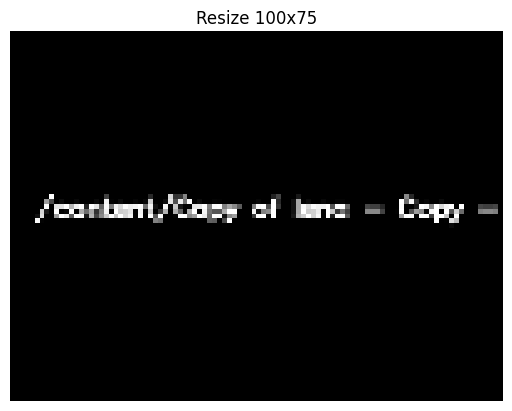

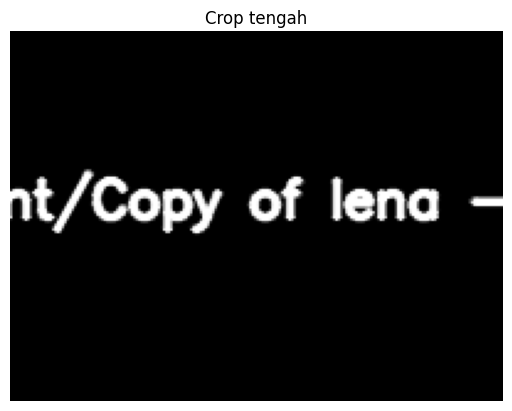

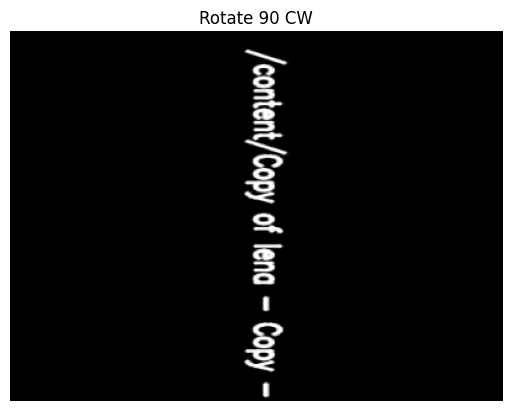

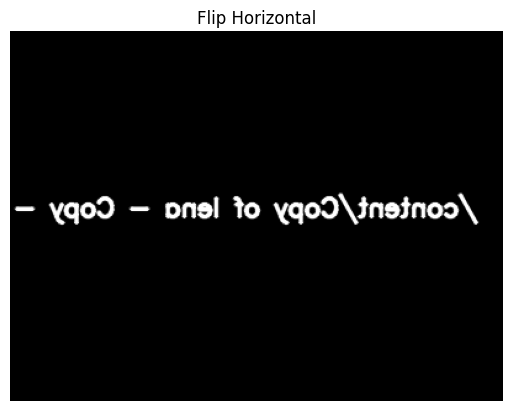

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os # Import os module to check for file existence

from google.colab.patches import cv2_imshow


# Try to read the image. If not found, create a dummy image.
if os.path.exists('image.jpg'):
    img = cv2.imread('image.jpg')
    print("Image 'image.jpg' loaded successfully.")
else:
    print("Image 'image.jpg' not found. Creating a dummy black image (300x400).")
    # Create a 300x400 black image with 3 channels (for RGB)
    img = np.zeros((300, 400, 3), dtype=np.uint8)
    # Optionally, add some text to make it more interesting
    cv2.putText(img, "/content/Copy of lena - Copy - Copy.jpg)", (20, 150), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)


h,w = img.shape[:2]
print("Baris = {}, Kolom = {}".format (h,w)) # Corrected print statement

ukuran = cv2.resize(img,(100,75))


ch,cw = h//4, w//4
crop = img[ch:ch+h//2, cw:cw+w//2]

rotasi = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
rotate = cv2.resize(rotasi,(w,h))

flip = cv2.flip(img,1)


def show(tittle,im):
  plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
  plt.title(tittle)
  plt.axis('off')
  plt.show()

for t,im in [("Resize 100x75", ukuran), ("Crop tengah", crop), ("Rotate 90 CW", rotate), ("Flip Horizontal", flip)]:
  show(t,im)


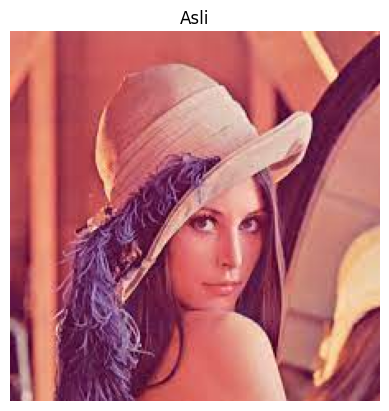

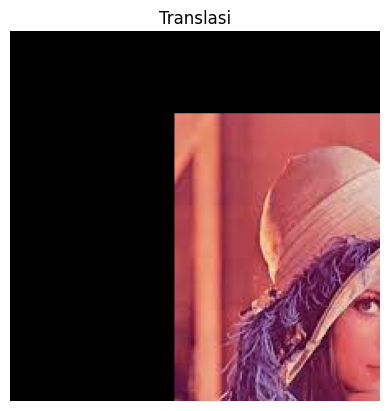

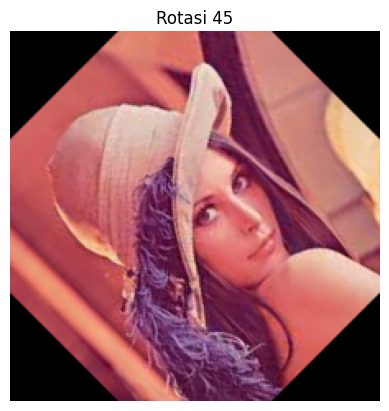

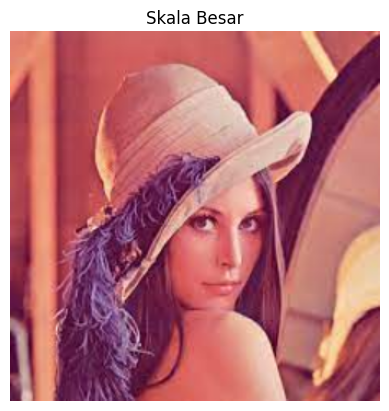

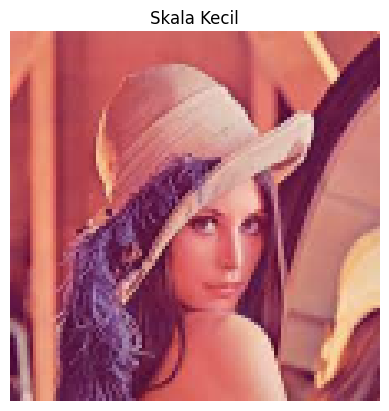

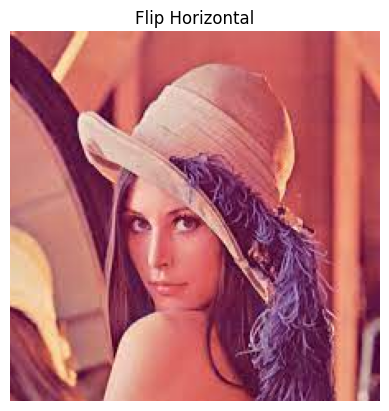

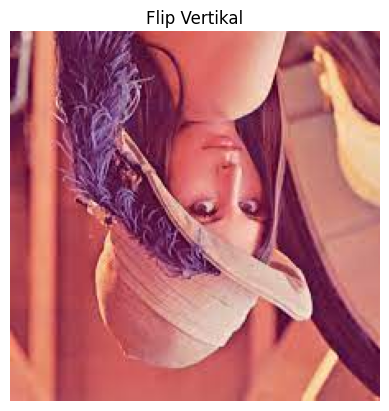

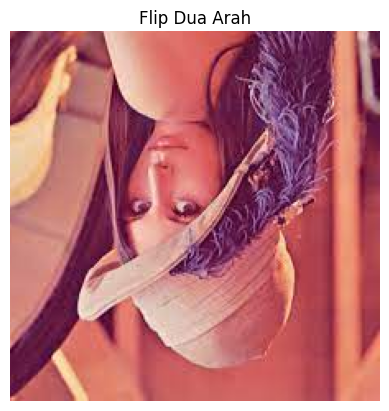

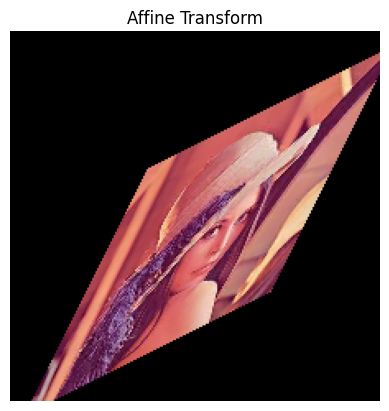

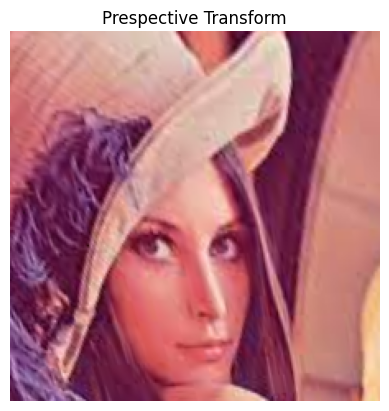

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow

path = "/content/Copy of lena - Copy - Copy.jpg"
img = cv2.imread(path)

if img is None:
  raise ValueError("Image not found")

# Unindent these lines so they are always executed after img is loaded
tinggi, lebar = img.shape[:2]



  # RANSLASI (GESER)
tx, ty = 100, 50 # Geser ke kanan 100px, turun 50px
matriks_translasi = np.float32([[1, 0, tx], [0, 1, ty]])
hasil_translasi = cv2.warpAffine(img, matriks_translasi, (lebar, tinggi))



# Rotasi (PUTAR)

sudut = 45 # derajat
pusat = (lebar // 2, tinggi // 2)
matriks_rotasi = cv2.getRotationMatrix2D(pusat, sudut, 1.0)
hasil_rotasi = cv2.warpAffine(img, matriks_rotasi, (lebar, tinggi))



# SKALA
hasil_skala_besar = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)
hasil_skala_kecil = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR)



# FLIP
flip_horizontal = cv2.flip(img, 1)  # 1 -> horizontal
flip_vertikal = cv2.flip(img, 0)    # 0 -> vertikal
flip_dua_arah = cv2.flip(img, -1)   # -1 -> horizontal dan vertikal


# AFFINE TRANSFORM

# Titik sumber (3 titik pada gambar asli)
pts1 = np.float32([[50, 50], [200, 50], [50, 200]]) # Corrected array syntax
# Titik tujuan (kemana titik itu dipindah)
pts2 = np.float32([[100, 100], [200, 50], [50,200]]) # Corrected array syntax
matriks_affine = cv2.getAffineTransform(pts1, pts2)
hasil_affine = cv2.warpAffine(img, matriks_affine, (lebar, tinggi))




# PERSPECTIVE TRANSFORM
# Both pts1 and pts2 must have exactly 4 points for getPerspectiveTransform
pts1= np.float32([[100,100],[400,100],[100,400],[400,400]]) # Added a fourth point
pts2= np.float32([[50,100],[450,100], [150, 450], [400,400]])
matriks_prespective = cv2.getPerspectiveTransform(pts1, pts2)
hasil_prespective = cv2.warpPerspective(img, matriks_prespective, (lebar, tinggi))
def show(tittle,im):
  plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); plt.title(tittle); plt.axis('off'); plt.show() # Corrected 'plt.tittle' to 'plt.title'


show("Asli", img)
show("Translasi", hasil_translasi)
show("Rotasi 45", hasil_rotasi)
show("Skala Besar", hasil_skala_besar)
show("Skala Kecil", hasil_skala_kecil)
show("Flip Horizontal", flip_horizontal)
show("Flip Vertikal", flip_vertikal)
show("Flip Dua Arah", flip_dua_arah)
show("Affine Transform", hasil_affine)
show("Prespective Transform", hasil_prespective)
cv2.waitKey(0) # Added argument 0 to waitKey to make it functional
cv2.destroyAllWindows()